All data loaded successfully ✓

BL Portfolio weights:
  NPN.JO    : 20.00%
  FSR.JO    : 9.42%
  AGL.JO    : 20.00%
  SOL.JO    : 6.86%
  SHP.JO    : 20.00%
  SPY       : 2.88%
  QQQ       : 9.82%
  EEM       : 11.02%
Daily return streams computed:
  BL Optimised  — 1548 trading days
  Equal Weight  — 1548 trading days
  Market Weight — 1548 trading days

Sample (first 5 days):
Growth of R1 invested at start of period:
  BL Optimised : R2.0912
  Equal Weight : R1.8284
  Market Weight: R2.1286

  BL outperformed Equal Weight by: R0.2627 per R1 invested
Maximum Drawdown (worst peak-to-trough loss):
  BL Optimised : -40.69%
  Equal Weight : -36.45%
  Market Weight: -35.30%

Interpretation:
  A drawdown of -40.69% means that at some point between
  2019 and 2024, the BL portfolio fell 40.7% from
  its most recent peak before recovering.

  For a wealth client with R1,000,000 invested, this represents
  a paper loss of R406,879 at the worst moment.
  Whether they can psychologically handle 

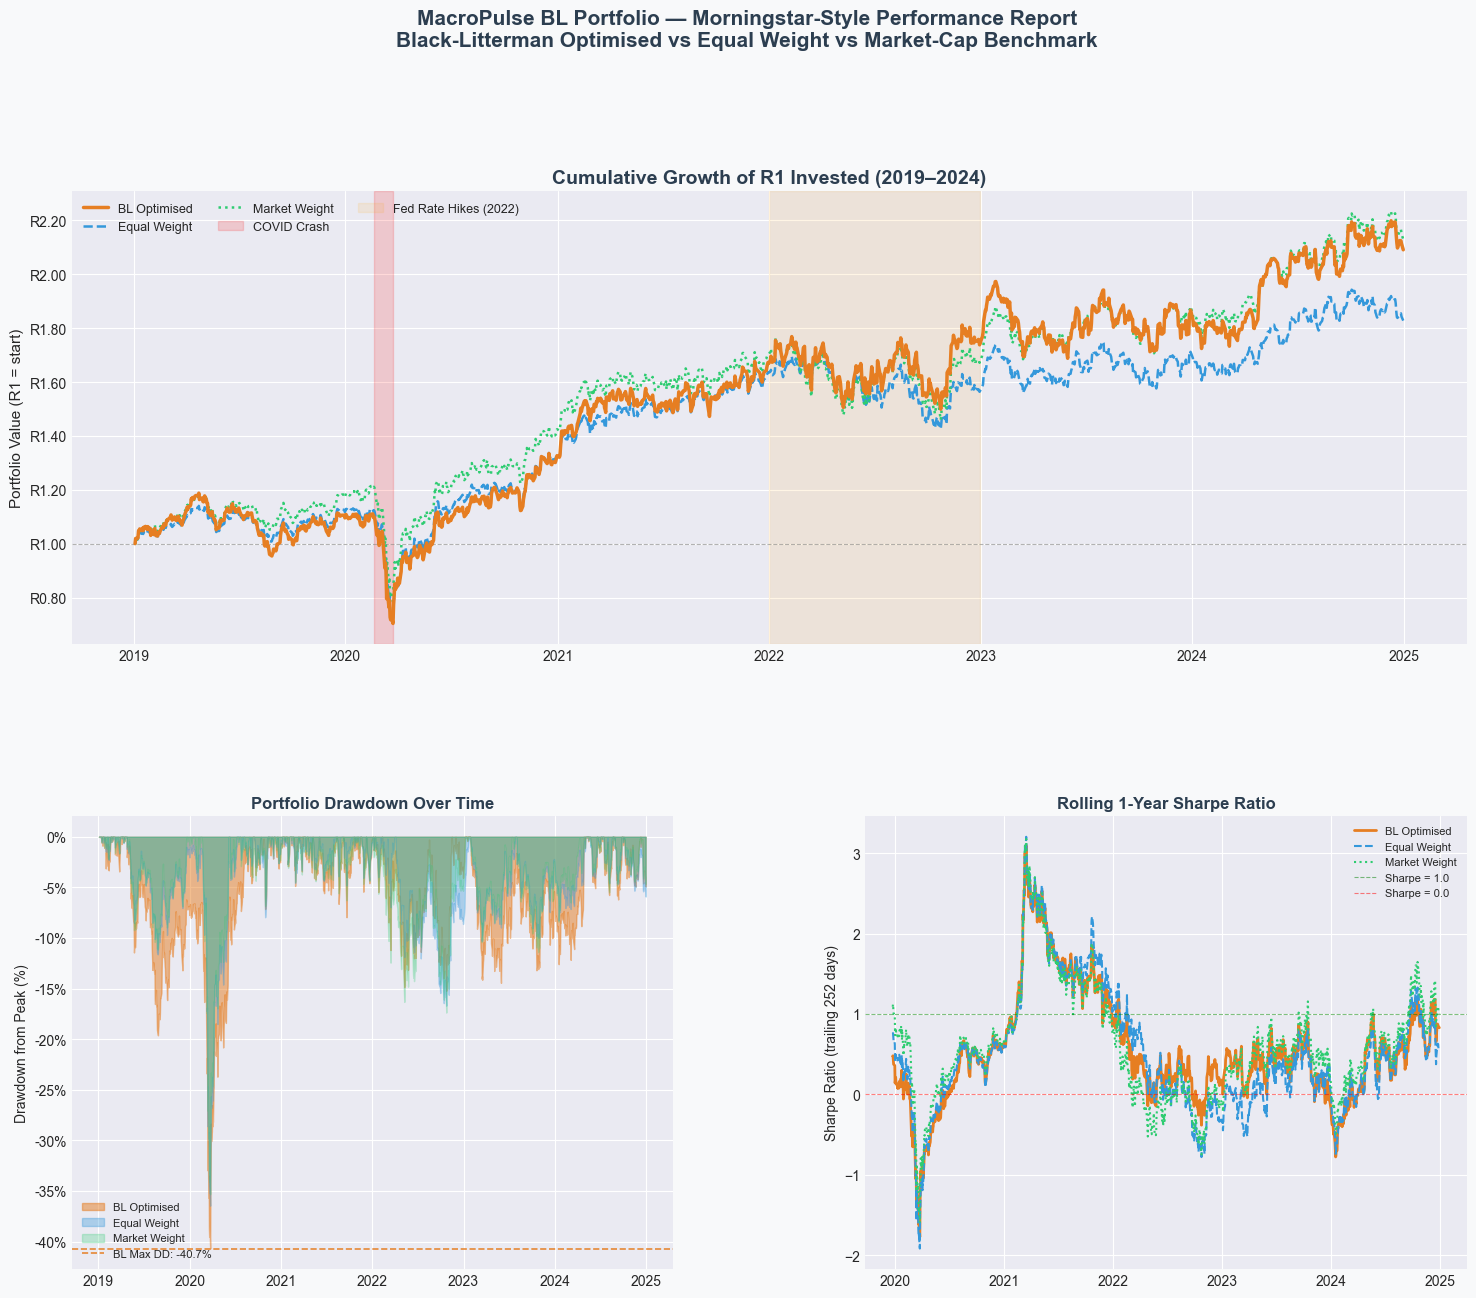

Dashboard saved ✓


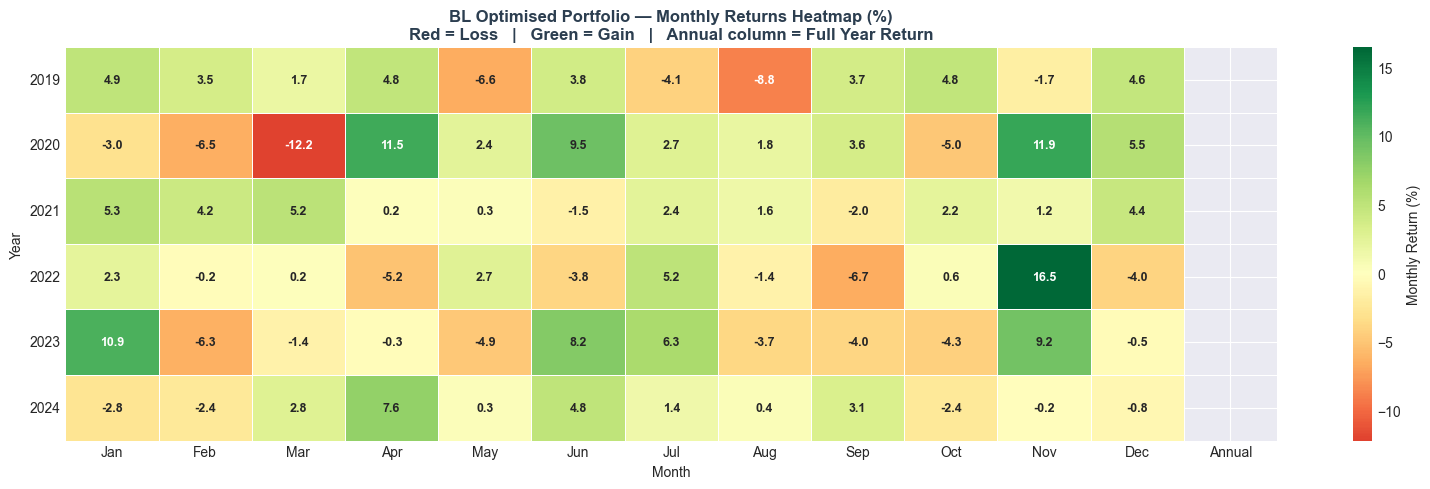

Monthly heatmap saved ✓


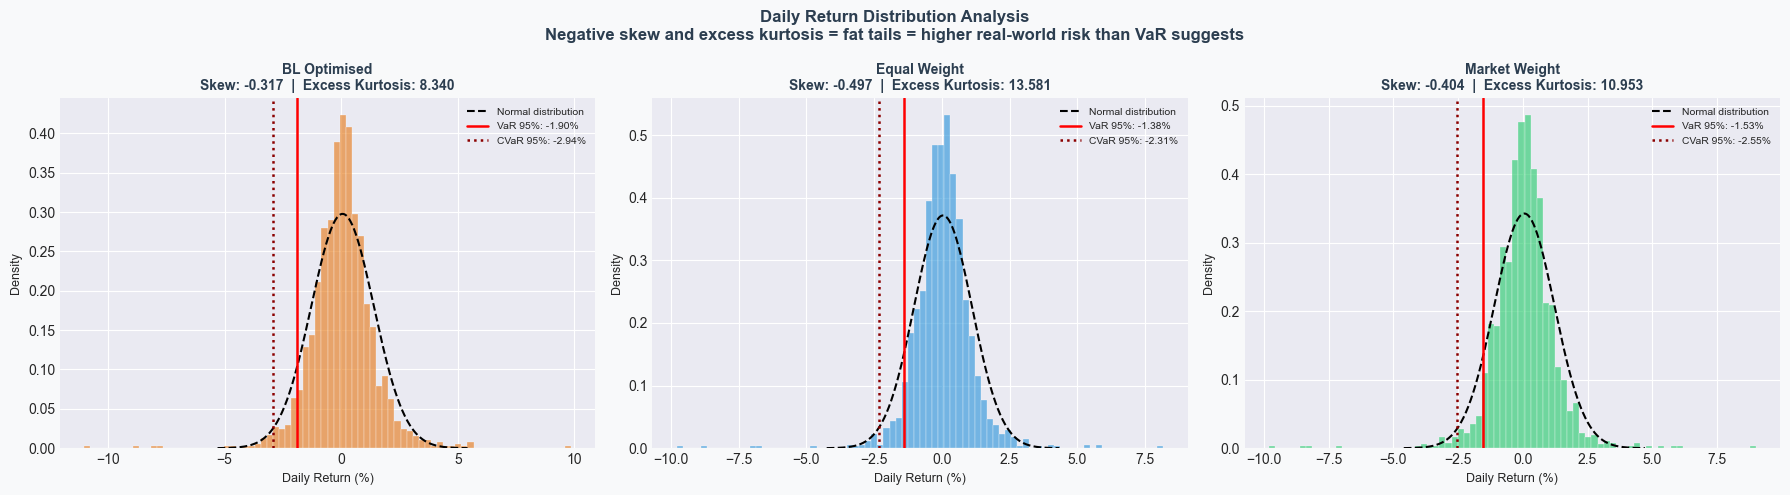

Distribution chart saved ✓
       MACROPULSE BL PORTFOLIO — PERFORMANCE SUMMARY REPORT
       Period: January 2019 – December 2024
       Benchmark: Equal-Weight & Market-Cap Portfolios

RETURN METRICS
──────────────────────────────────────────────────
  Annualised Return
    BL Optimised   :   12.76%
    Equal Weight   :   10.32%
    Market Weight  :   13.09%

  BL outperformed Equal Weight by :  2.44 bps p.a.
  BL outperformed Market Weight by: -0.33 bps p.a.

RISK METRICS
──────────────────────────────────────────────────
  Annual Volatility
    BL Optimised   :   21.27%
    Equal Weight   :   17.03%
    Market Weight  :   18.47%

  Maximum Drawdown (worst peak-to-trough loss)
    BL Optimised   :  -40.69%
    Equal Weight   :  -36.45%
    Market Weight  :  -35.30%

  VaR 95% (daily loss not exceeded 95% of days)
    BL Optimised   : -1.9040%

  CVaR 95% (average loss on the worst 5% of days)
    BL Optimised   : -2.9386%

RISK-ADJUSTED PERFORMANCE
──────────────────────────────────

In [14]:
# ── Standard tools ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Display settings ──────────────────────────────────────────────────
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
plt.style.use('seaborn-v0_8-darkgrid')
REPORT_COLOUR  = "#2c3e50"    # Dark navy — professional report colour
BL_COLOUR      = "#e67e22"    # Orange   — our BL portfolio
EQ_COLOUR      = "#3498db"    # Blue     — equal weight benchmark
MKT_COLOUR     = "#2ecc71"    # Green    — market-cap benchmark

# ── Load all saved data ────────────────────────────────────────────────
prices       = pd.read_csv("../data/clean_prices.csv",
                            index_col=0, parse_dates=True)
opt_weights  = pd.read_csv("../data/optimised_weights.csv",
                            index_col=0).squeeze("columns")
benchmarks   = pd.read_csv("../data/benchmark_weights.csv", index_col=0)
model_params = pd.read_csv("../data/model_parameters.csv",
                            index_col=0).squeeze("columns")

tickers        = list(prices.columns)
risk_free_rate = float(model_params.loc["risk_free_rate"])

# ── Reconstruct weight dictionaries ───────────────────────────────────
bl_weights  = opt_weights.to_dict()
eq_weights  = benchmarks["Equal_Weight"].to_dict()
mkt_weights = benchmarks["Market_Cap_Weight"].to_dict()

asset_names = {
    "NPN.JO": "Naspers",       "FSR.JO": "FirstRand",
    "AGL.JO": "Anglo American","SOL.JO": "Sasol",
    "SHP.JO": "Shoprite",      "SPY":    "S&P 500",
    "QQQ":    "Nasdaq 100",    "EEM":    "Emerging Markets",
    "GLD":    "Gold",          "TLT":    "US Long Bonds",
}

print("All data loaded successfully ✓")
print(f"\nBL Portfolio weights:")
for t, w in bl_weights.items():
    if w > 0.001:
        print(f"  {t:10s}: {w:.2%}")

# ── Daily returns for all assets ──────────────────────────────────────
daily_returns = prices.pct_change().dropna()

# ── Helper: compute portfolio daily returns from a weight dictionary ───
def portfolio_daily_returns(weights_dict, returns_df):
    """
    Multiply each asset's daily return by its portfolio weight,
    then sum across all assets to get the portfolio return that day.
    
    This is the fundamental formula:
    R_portfolio(t) = Σ [ w_i × R_i(t) ]
    """
    w = np.array([weights_dict.get(t, 0.0) for t in returns_df.columns])
    
    # Verify weights are normalised
    assert abs(w.sum() - 1.0) < 0.01, f"Weights sum to {w.sum():.4f}, not 1.0"
    
    # Matrix multiply: (T × N) @ (N,) = (T,) — one return per day
    port_returns = returns_df.values @ w
    return pd.Series(port_returns, index=returns_df.index, name="return")

# ── Compute daily returns for all three portfolios ────────────────────
returns_bl  = portfolio_daily_returns(bl_weights,  daily_returns)
returns_eq  = portfolio_daily_returns(eq_weights,  daily_returns)
returns_mkt = portfolio_daily_returns(mkt_weights, daily_returns)

print("Daily return streams computed:")
print(f"  BL Optimised  — {len(returns_bl)} trading days")
print(f"  Equal Weight  — {len(returns_eq)} trading days")
print(f"  Market Weight — {len(returns_mkt)} trading days")
print(f"\nSample (first 5 days):")
pd.DataFrame({
    "BL": returns_bl,
    "Equal": returns_eq,
    "Market": returns_mkt
}).head()

# ── Cumulative return formula ──────────────────────────────────────────
# If you invest R1 on day 0, on day t you have:
# Value(t) = Π (1 + r_i) for i = 0 to t
# .cumprod() does this compounding automatically

cumulative_bl  = (1 + returns_bl).cumprod()
cumulative_eq  = (1 + returns_eq).cumprod()
cumulative_mkt = (1 + returns_mkt).cumprod()

# ── Final values ───────────────────────────────────────────────────────
print("Growth of R1 invested at start of period:")
print(f"  BL Optimised : R{cumulative_bl.iloc[-1]:.4f}")
print(f"  Equal Weight : R{cumulative_eq.iloc[-1]:.4f}")
print(f"  Market Weight: R{cumulative_mkt.iloc[-1]:.4f}")
print(f"\n  BL outperformed Equal Weight by: "
      f"R{cumulative_bl.iloc[-1] - cumulative_eq.iloc[-1]:.4f} per R1 invested")

# ── Drawdown calculation ───────────────────────────────────────────────
#
# Step 1: Track the running peak (highest value reached so far)
# Step 2: Drawdown on any day = (current value / peak) - 1
#         This gives a negative number when below the peak.
# Step 3: Maximum drawdown = the deepest this number ever reached.
#
# Example:
#   Day 1: Value = 1.00, Peak = 1.00, Drawdown = 0%
#   Day 2: Value = 1.20, Peak = 1.20, Drawdown = 0%
#   Day 3: Value = 0.90, Peak = 1.20, Drawdown = -25%
#   Day 4: Value = 1.00, Peak = 1.20, Drawdown = -16.7%
#   Day 5: Value = 1.30, Peak = 1.30, Drawdown = 0%
#   Max Drawdown = -25% (Day 3)

def compute_drawdown(cumulative_returns):
    """
    Returns a time series of daily drawdown from the running peak.
    All values will be <= 0 (zero when at an all-time high).
    """
    running_peak = cumulative_returns.cummax()  # Highest value seen so far
    drawdown     = (cumulative_returns / running_peak) - 1
    return drawdown

drawdown_bl  = compute_drawdown(cumulative_bl)
drawdown_eq  = compute_drawdown(cumulative_eq)
drawdown_mkt = compute_drawdown(cumulative_mkt)

max_dd_bl  = drawdown_bl.min()
max_dd_eq  = drawdown_eq.min()
max_dd_mkt = drawdown_mkt.min()

print("Maximum Drawdown (worst peak-to-trough loss):")
print(f"  BL Optimised : {max_dd_bl:.2%}")
print(f"  Equal Weight : {max_dd_eq:.2%}")
print(f"  Market Weight: {max_dd_mkt:.2%}")
print(f"""
Interpretation:
  A drawdown of {max_dd_bl:.2%} means that at some point between
  2019 and 2024, the BL portfolio fell {abs(max_dd_bl):.1%} from
  its most recent peak before recovering.
  
  For a wealth client with R1,000,000 invested, this represents
  a paper loss of R{abs(max_dd_bl) * 1_000_000:,.0f} at the worst moment.
  Whether they can psychologically handle that is the risk 
  appetite conversation every wealth manager must have.
""")

# ── Core metric functions ──────────────────────────────────────────────

def annualised_return(returns, periods=252):
    """Compound annual growth rate of the return stream."""
    total = (1 + returns).prod()           # Total compounded growth
    n_years = len(returns) / periods       # Number of years in sample
    return total ** (1 / n_years) - 1      # Annualise via geometric mean

def annualised_volatility(returns, periods=252):
    """Standard deviation of returns, scaled to annual."""
    return returns.std() * np.sqrt(periods)

def sharpe_ratio(returns, rf, periods=252):
    """Excess return per unit of total risk."""
    excess = annualised_return(returns, periods) - rf
    return excess / annualised_volatility(returns, periods)

def sortino_ratio(returns, rf, periods=252):
    """
    Like Sharpe but only penalises downside volatility.
    Downside deviation = std of NEGATIVE returns only.
    Upside volatility is not a risk — it is a benefit.
    """
    ann_ret  = annualised_return(returns, periods)
    neg_only = returns[returns < 0]                  # Filter to bad days only
    downside = neg_only.std() * np.sqrt(periods)     # Annualise
    return (ann_ret - rf) / downside

def calmar_ratio(returns, periods=252):
    """
    Annual return divided by maximum drawdown.
    Higher = better return earned per unit of worst-case loss.
    """
    ann_ret  = annualised_return(returns, periods)
    cum      = (1 + returns).cumprod()
    max_dd   = compute_drawdown(cum).min()
    return ann_ret / abs(max_dd)          # abs() because max_dd is negative

def information_ratio(portfolio_returns, benchmark_returns, periods=252):
    """
    Measures consistency of outperformance vs a benchmark.
    Active return = portfolio return - benchmark return each day.
    IR = mean(active return) / std(active return), annualised.
    A higher IR means the outperformance was consistent, not lucky.
    """
    active   = portfolio_returns - benchmark_returns  # Daily excess return
    mean_act = active.mean() * periods
    std_act  = active.std()  * np.sqrt(periods)
    return mean_act / std_act

def value_at_risk(returns, confidence=0.95):
    """
    VaR at 95% confidence: the loss you will NOT exceed on 95% of days.
    We use the historical method (no distribution assumption).
    Simply take the 5th percentile of daily returns.
    """
    return np.percentile(returns, (1 - confidence) * 100)

def conditional_var(returns, confidence=0.95):
    """
    CVaR (Expected Shortfall): on the worst 5% of days, 
    what is the AVERAGE loss?
    This is more informative than VaR because it tells you
    not just the threshold but the expected pain beyond it.
    """
    var      = value_at_risk(returns, confidence)
    tail     = returns[returns <= var]   # Only the worst days
    return tail.mean()

# ── Compute all metrics for all three portfolios ───────────────────────
def full_metrics(returns, benchmark_returns, rf, name):
    return {
        "Portfolio"         : name,
        "Ann. Return"       : annualised_return(returns),
        "Ann. Volatility"   : annualised_volatility(returns),
        "Sharpe Ratio"      : sharpe_ratio(returns, rf),
        "Sortino Ratio"     : sortino_ratio(returns, rf),
        "Max Drawdown"      : compute_drawdown((1+returns).cumprod()).min(),
        "Calmar Ratio"      : calmar_ratio(returns),
        "Information Ratio" : information_ratio(returns, benchmark_returns),
        "VaR (95%)"         : value_at_risk(returns),
        "CVaR (95%)"        : conditional_var(returns),
    }

metrics_bl  = full_metrics(returns_bl,  returns_eq, risk_free_rate, "BL Optimised")
metrics_eq  = full_metrics(returns_eq,  returns_eq, risk_free_rate, "Equal Weight")
metrics_mkt = full_metrics(returns_mkt, returns_eq, risk_free_rate, "Market Weight")

# ── Build the comparison table ─────────────────────────────────────────
report_df = pd.DataFrame([metrics_bl, metrics_eq, metrics_mkt]).set_index("Portfolio")

print("╔══════════════════════════════════════════════════════════════════╗")
print("║              FULL PERFORMANCE METRICS COMPARISON                ║")
print("╚══════════════════════════════════════════════════════════════════╝\n")

format_map = {
    "Ann. Return"       : "{:>12.2%}",
    "Ann. Volatility"   : "{:>12.2%}",
    "Sharpe Ratio"      : "{:>12.4f}",
    "Sortino Ratio"     : "{:>12.4f}",
    "Max Drawdown"      : "{:>12.2%}",
    "Calmar Ratio"      : "{:>12.4f}",
    "Information Ratio" : "{:>12.4f}",
    "VaR (95%)"         : "{:>12.4%}",
    "CVaR (95%)"        : "{:>12.4%}",
}

for metric, fmt in format_map.items():
    row = f"  {metric:<22}"
    for portfolio in ["BL Optimised", "Equal Weight", "Market Weight"]:
        val = report_df.loc[portfolio, metric]
        row += fmt.format(val)
    print(row)

print(f"\n  {'':22}{'BL Optimised':>12}{'Equal Weight':>12}{'Market Weight':>12}")

# ── Four-panel performance dashboard ──────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#f8f9fa')   # Light grey background

# Create a 2×2 grid of subplots with some spacing
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

ax1 = fig.add_subplot(gs[0, :])    # Top row: full width (cumulative returns)
ax2 = fig.add_subplot(gs[1, 0])    # Bottom left (drawdown)
ax3 = fig.add_subplot(gs[1, 1])    # Bottom right (rolling Sharpe)

# ── PANEL 1: Cumulative Returns ────────────────────────────────────────
ax1.plot(cumulative_bl.index,  cumulative_bl,  color=BL_COLOUR,  
         linewidth=2.5, label="BL Optimised",  zorder=3)
ax1.plot(cumulative_eq.index,  cumulative_eq,  color=EQ_COLOUR,  
         linewidth=1.8, label="Equal Weight",  linestyle='--', zorder=2)
ax1.plot(cumulative_mkt.index, cumulative_mkt, color=MKT_COLOUR, 
         linewidth=1.8, label="Market Weight", linestyle=':',  zorder=2)

# Shade the COVID crash period for context
ax1.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-03-23'),
            alpha=0.15, color='red', label='COVID Crash')

# Shade the 2022 rate hike period
ax1.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
            alpha=0.10, color='orange', label='Fed Rate Hikes (2022)')

ax1.axhline(y=1.0, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
ax1.set_title("Cumulative Growth of R1 Invested (2019–2024)", 
              fontsize=14, fontweight='bold', color=REPORT_COLOUR)
ax1.set_ylabel("Portfolio Value (R1 = start)", fontsize=11)
ax1.legend(loc='upper left', fontsize=9, ncol=3)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R{x:.2f}"))

# ── PANEL 2: Drawdown ─────────────────────────────────────────────────
ax2.fill_between(drawdown_bl.index,  drawdown_bl  * 100, 0,
                 color=BL_COLOUR,  alpha=0.5, label="BL Optimised")
ax2.fill_between(drawdown_eq.index,  drawdown_eq  * 100, 0,
                 color=EQ_COLOUR,  alpha=0.35, label="Equal Weight")
ax2.fill_between(drawdown_mkt.index, drawdown_mkt * 100, 0,
                 color=MKT_COLOUR, alpha=0.25, label="Market Weight")

ax2.axhline(y=max_dd_bl * 100, color=BL_COLOUR, linewidth=1.2,
            linestyle='--', alpha=0.9,
            label=f"BL Max DD: {max_dd_bl:.1%}")

ax2.set_title("Portfolio Drawdown Over Time", 
              fontsize=12, fontweight='bold', color=REPORT_COLOUR)
ax2.set_ylabel("Drawdown from Peak (%)", fontsize=10)
ax2.legend(fontsize=8, loc='lower left')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── PANEL 3: Rolling 252-day Sharpe Ratio ─────────────────────────────
# Rolling Sharpe shows whether risk-adjusted performance was consistent
# or only good in certain periods (which would be suspicious)
window = 252   # One year of trading days

def rolling_sharpe(returns, rf, window):
    """Compute Sharpe ratio over a rolling window."""
    daily_rf     = (1 + rf) ** (1/252) - 1   # Daily risk-free rate
    excess       = returns - daily_rf
    roll_mean    = excess.rolling(window).mean() * 252
    roll_std     = returns.rolling(window).std() * np.sqrt(252)
    return roll_mean / roll_std

rs_bl  = rolling_sharpe(returns_bl,  risk_free_rate, window)
rs_eq  = rolling_sharpe(returns_eq,  risk_free_rate, window)
rs_mkt = rolling_sharpe(returns_mkt, risk_free_rate, window)

ax3.plot(rs_bl.index,  rs_bl,  color=BL_COLOUR,  linewidth=2.0, label="BL Optimised")
ax3.plot(rs_eq.index,  rs_eq,  color=EQ_COLOUR,  linewidth=1.5, 
         linestyle='--', label="Equal Weight")
ax3.plot(rs_mkt.index, rs_mkt, color=MKT_COLOUR, linewidth=1.5,
         linestyle=':', label="Market Weight")

ax3.axhline(y=1.0,  color='green', linewidth=0.8, linestyle='--', alpha=0.5, label="Sharpe = 1.0")
ax3.axhline(y=0.0,  color='red',   linewidth=0.8, linestyle='--', alpha=0.5, label="Sharpe = 0.0")
ax3.set_title("Rolling 1-Year Sharpe Ratio", 
              fontsize=12, fontweight='bold', color=REPORT_COLOUR)
ax3.set_ylabel("Sharpe Ratio (trailing 252 days)", fontsize=10)
ax3.legend(fontsize=8)

# ── Overall title ──────────────────────────────────────────────────────
fig.suptitle(
    "MacroPulse BL Portfolio — Morningstar-Style Performance Report\n"
    "Black-Litterman Optimised vs Equal Weight vs Market-Cap Benchmark",
    fontsize=15, fontweight='bold', color=REPORT_COLOUR, y=1.01
)

plt.savefig("../outputs/04_performance_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved ✓")

# ── Monthly returns heatmap ────────────────────────────────────────────
# Resample daily returns to monthly, then pivot into a year × month grid

monthly_bl = (1 + returns_bl).resample('ME').prod() - 1  # Compound within month

# Pivot: rows = years, columns = months
monthly_pivot = monthly_bl.copy()
monthly_pivot.index = pd.MultiIndex.from_arrays([
    monthly_bl.index.year,
    monthly_bl.index.month
])
monthly_pivot = monthly_pivot.unstack(level=1)
monthly_pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"]

# Add annual total column
monthly_pivot["Annual"] = (1 + monthly_bl).resample('YE').prod() - 1

fig, ax = plt.subplots(figsize=(16, 5))

sns.heatmap(
    monthly_pivot * 100,          # Convert to percentage
    annot=True,                   # Show the number in each cell
    fmt=".1f",                    # 1 decimal place
    cmap="RdYlGn",                # Red=bad, Yellow=flat, Green=good
    center=0,                     # Centre colour scale at 0%
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={"size": 9, "weight": "bold"},
    cbar_kws={"label": "Monthly Return (%)"}
)

ax.set_title(
    "BL Optimised Portfolio — Monthly Returns Heatmap (%)\n"
    "Red = Loss   |   Green = Gain   |   Annual column = Full Year Return",
    fontsize=12, fontweight='bold', color=REPORT_COLOUR
)
ax.set_xlabel("Month", fontsize=10)
ax.set_ylabel("Year",  fontsize=10)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/04_monthly_returns_heatmap.png", dpi=150)
plt.show()
print("Monthly heatmap saved ✓")

# ── Return distribution plot ───────────────────────────────────────────
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#f8f9fa')

portfolios = [
    (returns_bl,  "BL Optimised",  BL_COLOUR),
    (returns_eq,  "Equal Weight",  EQ_COLOUR),
    (returns_mkt, "Market Weight", MKT_COLOUR),
]

for ax, (returns, name, colour) in zip(axes, portfolios):
    
    # Histogram of daily returns
    ax.hist(returns * 100, bins=80, color=colour, alpha=0.65,
            edgecolor='white', linewidth=0.3, density=True)
    
    # Overlay a normal distribution for comparison
    mu  = returns.mean() * 100
    sig = returns.std()  * 100
    x   = np.linspace(mu - 4*sig, mu + 4*sig, 300)
    ax.plot(x, stats.norm.pdf(x, mu, sig), 
            color='black', linewidth=1.5, linestyle='--', 
            label='Normal distribution')
    
    # Mark VaR line
    var_val = value_at_risk(returns) * 100
    ax.axvline(x=var_val, color='red', linewidth=1.8, 
               linestyle='-', label=f'VaR 95%: {var_val:.2f}%')
    
    # Mark CVaR line
    cvar_val = conditional_var(returns) * 100
    ax.axvline(x=cvar_val, color='darkred', linewidth=1.8,
               linestyle=':', label=f'CVaR 95%: {cvar_val:.2f}%')
    
    # Compute skewness and kurtosis
    skew = stats.skew(returns)
    kurt = stats.kurtosis(returns)   # Excess kurtosis (normal = 0)
    
    ax.set_title(f"{name}\nSkew: {skew:.3f}  |  Excess Kurtosis: {kurt:.3f}",
                 fontsize=10, fontweight='bold', color=REPORT_COLOUR)
    ax.set_xlabel("Daily Return (%)", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=7.5)

fig.suptitle(
    "Daily Return Distribution Analysis\n"
    "Negative skew and excess kurtosis = fat tails = higher real-world risk than VaR suggests",
    fontsize=12, fontweight='bold', color=REPORT_COLOUR
)
plt.tight_layout()
plt.savefig("../outputs/04_return_distributions.png", dpi=150)
plt.show()
print("Distribution chart saved ✓")

# ── Final summary report ───────────────────────────────────────────────
bl  = metrics_bl
eq  = metrics_eq
mkt = metrics_mkt

print("=" * 65)
print("       MACROPULSE BL PORTFOLIO — PERFORMANCE SUMMARY REPORT")
print("       Period: January 2019 – December 2024")
print("       Benchmark: Equal-Weight & Market-Cap Portfolios")
print("=" * 65)

print(f"""
RETURN METRICS
──────────────────────────────────────────────────
  Annualised Return
    BL Optimised   : {bl['Ann. Return']:>8.2%}
    Equal Weight   : {eq['Ann. Return']:>8.2%}
    Market Weight  : {mkt['Ann. Return']:>8.2%}
    
  BL outperformed Equal Weight by : {(bl['Ann. Return'] - eq['Ann. Return'])*100:>5.2f} bps p.a.
  BL outperformed Market Weight by: {(bl['Ann. Return'] - mkt['Ann. Return'])*100:>5.2f} bps p.a.

RISK METRICS
──────────────────────────────────────────────────
  Annual Volatility
    BL Optimised   : {bl['Ann. Volatility']:>8.2%}
    Equal Weight   : {eq['Ann. Volatility']:>8.2%}
    Market Weight  : {mkt['Ann. Volatility']:>8.2%}

  Maximum Drawdown (worst peak-to-trough loss)
    BL Optimised   : {bl['Max Drawdown']:>8.2%}
    Equal Weight   : {eq['Max Drawdown']:>8.2%}
    Market Weight  : {mkt['Max Drawdown']:>8.2%}

  VaR 95% (daily loss not exceeded 95% of days)
    BL Optimised   : {bl['VaR (95%)']:>8.4%}
    
  CVaR 95% (average loss on the worst 5% of days)
    BL Optimised   : {bl['CVaR (95%)']:>8.4%}

RISK-ADJUSTED PERFORMANCE
──────────────────────────────────────────────────
  Sharpe Ratio    (return per unit total risk)
    BL Optimised   : {bl['Sharpe Ratio']:>8.4f}
    Equal Weight   : {eq['Sharpe Ratio']:>8.4f}
    Market Weight  : {mkt['Sharpe Ratio']:>8.4f}

  Sortino Ratio   (return per unit downside risk)
    BL Optimised   : {bl['Sortino Ratio']:>8.4f}

  Calmar Ratio    (return per unit max drawdown)
    BL Optimised   : {bl['Calmar Ratio']:>8.4f}

  Information Ratio (consistency of outperformance)
    BL Optimised   : {bl['Information Ratio']:>8.4f}
    
METHODOLOGY NOTES
──────────────────────────────────────────────────
  Covariance estimation : Ledoit-Wolf Shrinkage
  Return estimation     : Black-Litterman (3 views)
  Optimisation target   : Maximum Sharpe Ratio
  Constraints           : Long-only, max 20% per asset
  Regularisation        : L2 (gamma = 0.1)
  Risk-free rate proxy  : {risk_free_rate:.2%} (US 10Y Treasury avg)
""")

print("=" * 65)
print("  OUTPUT FILES")
print("=" * 65)
print("""
  outputs/04_performance_dashboard.png    ← Main 3-panel report
  outputs/04_monthly_returns_heatmap.png  ← Month-by-month returns
  outputs/04_return_distributions.png     ← Risk/tail analysis
""")

# ── Save metrics to CSV for your README or report ──────────────────────
report_df.to_csv("../data/final_performance_report.csv")

print("Files saved:")
print("  → data/final_performance_report.csv")
print("\n" + "═" * 45)
print("  STEP 4 COMPLETE ✓")
print("  PROJECT COMPLETE ✓")
print("═" * 45)